# KeyBERT + MMR Reranker

**전체 파이프라인**
```
KP20K (500 samples)
        ↓
[Stage 1] KeyBART — 후보 키프레이즈 생성
        ↓
[Stage 2] KeyBERT Reranking — 문서-후보 코사인 유사도로 1차 순위
        ↓
[Stage 3] MMR — 의미 중복 제거(다양성 확보)
        ↓
Evaluation — F1@5, F1@M
```

**핵심 아이디어**
- KeyBERT: 임베딩 모델로 문서와 후보 키프레이즈를 인코딩 → 코사인 유사도 기반 1차 순위
- MMR: `λ × relevance - (1-λ) × redundancy` 로 반복 표현 억제, λ로 trade-off 조절

In [1]:
# 필요 패키지 설치
!pip install transformers datasets==3.6.0 sentence-transformers scikit-learn nltk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.7 MB/s eta 0:00:0000:01


## Config — 실험 파라미터

In [2]:
# ── 전체 파이프라인에서 사용할 하이퍼파라미터 ──────────────────────
# 여기서 값을 바꾸면 아래 셀 전체에 반영됩니다.
CONFIG = {
    # ── 데이터 ────────────────────────────────────────────────
    'num_samples': 500,           # 실험에 사용할 샘플 수 (즉시 실행 가능 규모)
    'split': 'test',              # 평가 split ('test' | 'validation')

    # ── KeyBART 후보 생성 ────────────────────────────────────
    'keybart_model': 'bloomberg/KeyBART',
    'num_beams': 10,              # Beam search 너비
    'num_return_sequences': 10,   # 반환 시퀀스 수 (beam 수 이하)
    'keybart_max_len': 60,        # 생성 최대 토큰 수

    # ── 후보 전처리 ─────────────────────────────────────────
    'min_words': 1,
    'max_words': 5,

    # ── KeyBERT 임베딩 모델 ──────────────────────────────────
    # 옵션 A (범용 고성능):  'sentence-transformers/all-mpnet-base-v2'
    # 옵션 B (학술 도메인):  'allenai/scibert_scivocab_uncased'
    'encoder_model': 'sentence-transformers/all-mpnet-base-v2',

    # ── MMR ─────────────────────────────────────────────────
    # λ=1.0 → 순수 relevance (다양성 무시)
    # λ=0.0 → 순수 diversity (relevance 무시)
    # λ=0.5~0.7 → 일반적으로 좋은 균형
    'mmr_lambda': 0.6,

    # ── 출력 / 평가 ──────────────────────────────────────────
    'top_k': 10,                  # MMR이 최종 선택할 키프레이즈 수
    'eval_k': 5,                  # F1@K 에서 K
}

## Imports & Device Setup

In [ ]:
import re
import time
import torch
import numpy as np
import nltk
import json

import pandas as pd
import matplotlib.pyplot as plt
from transformers import BartForConditionalGeneration, AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from datasets import load_dataset
from nltk.stem import PorterStemmer
from tqdm.auto import tqdm

nltk.download('punkt', quiet=True)

# GPU 사용 가능 여부 확인
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Stage 1-A: 데이터 로드 (KP20K)

In [4]:
dataset = load_dataset('taln-ls2n/kp20k', trust_remote_code=True)

# CONFIG['num_samples']개 샘플만 사용 (빠른 실험)
eval_data = dataset[CONFIG['split']].select(range(CONFIG['num_samples']))

print(f'Loaded {len(eval_data)} samples from "{CONFIG['split']}" split')
print('\n[Sample]')
print('Title     :', eval_data[0]['title'])
print('Keyphrases:', eval_data[0]['keyphrases'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

kp20k.py: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

BuilderConfig(name='raw', version=0.0.1, data_dir=None, data_files=None, description='This part of my dataset covers the raw data')


...

validation.json:   0%|          | 0.00/25.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/530809 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Loaded 500 samples from "test" split

[Sample]
Title     : A feedback vertex set of 2-degenerate graphs
Keyphrases: ['feedback vertex set', '2-degenerate graphs', 'decycling set']


## Stage 1-B: KeyBART 후보 키프레이즈 생성

- `bloomberg/KeyBART` 는 학술 논문 요약 → 키프레이즈 생성에 특화된 BART 모델
- Beam Search로 여러 후보 시퀀스를 생성하고, 세미콜론(`;`)으로 개별 키프레이즈를 분리

In [5]:
# ── KeyBART 모델 & 토크나이저 로드 ─────────────────────────────
print(f'Loading KeyBART: {CONFIG["keybart_model"]} ...')
kp_tokenizer = AutoTokenizer.from_pretrained(CONFIG['keybart_model'])
kp_model = BartForConditionalGeneration.from_pretrained(CONFIG['keybart_model']).to(DEVICE)
kp_model.eval()  # 추론 모드 (dropout 비활성화)
print('KeyBART loaded.')


def generate_candidates(title: str, abstract: str) -> list:
    """
    KeyBART Beam Search로 후보 키프레이즈 생성.

    입력 형식: "<title> . <abstract>"
    출력 형식: KeyBART가 생성한 "kp1;kp2;kp3;..." 를 분리한 리스트

    Args:
        title    : 논문 제목
        abstract : 논문 초록

    Returns:
        중복 제거된 후보 키프레이즈 리스트
    """
    # 제목과 초록을 ' . '로 연결 (KeyBART 학습 포맷)
    text = title + ' . ' + abstract
    inputs = kp_tokenizer(
        text,
        return_tensors='pt',
        max_length=512,
        truncation=True      # 512 토큰 초과 시 잘라냄
    ).to(DEVICE)

    with torch.no_grad():
        outputs = kp_model.generate(
            **inputs,
            num_beams=CONFIG['num_beams'],
            num_return_sequences=CONFIG['num_return_sequences'],
            max_length=CONFIG['keybart_max_len'],
            no_repeat_ngram_size=3,  # 3-gram 반복 생성 방지
        )

    # 각 시퀀스를 디코딩한 뒤 세미콜론(;)으로 개별 키프레이즈 분리
    candidates = []
    for seq in kp_tokenizer.batch_decode(outputs, skip_special_tokens=True):
        for kp in seq.split(';'):
            kp = kp.strip()
            if kp:                   # 빈 문자열 제거
                candidates.append(kp)

    # 중복 제거 (순서 유지: 높은 beam score 순서 보존) 
    seen, unique = set(), []
    for kp in candidates:
        if kp not in seen:
            seen.add(kp)
            unique.append(kp)

    return unique

Loading KeyBART: bloomberg/KeyBART ...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


KeyBART loaded.


In [6]:
# GPU 환경에서 약 5~10분 소요
records = []
for sample in tqdm(eval_data, desc='[Stage 1] KeyBART generating'):
    candidates = generate_candidates(sample['title'], sample['abstract'])
    records.append({
        'title':      sample['title'],
        'abstract':   sample['abstract'],
        'keyphrases': sample['keyphrases'],   
        'candidates': candidates,             # KeyBART 생성 후보
    })

ex = records[0]
print(f'\n[Example]')
print(f'Title    : {ex["title"]}')
print(f'Gold KPs : {ex["keyphrases"]}')
print(f'Cands({len(ex["candidates"])}): {ex["candidates"]}')

[Stage 1] KeyBART generating:   0%|          | 0/500 [00:00<?, ?it/s]


[Example]
Title    : A feedback vertex set of 2-degenerate graphs
Gold KPs : ['feedback vertex set', '2-degenerate graphs', 'decycling set']
Cands(15): ['2-degenerate n -vertex graph', 'feedback vertex set of cardinality', 'polynomial time algorithm', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that this bound is tight', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper', 'we show that this bound is', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that the cardinality of', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that the cardinality of', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that this bound is tight', 'the cardinality of feedback vertex', 'the cardinality of a minimum', 'the cardinality of a feedback', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. key words: feedback vertex sets', '2-degre

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 데이터 저장
save_path = "/content/drive/MyDrive/멋쟁이사자처럼/keyphrase-extraction/keybart_candidates.json"

with open(save_path, "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=4)

print(f"✅ {len(records)}개의 추출 데이터가 '{save_path}'에 성공적으로 저장되었습니다.")

✅ 500개의 추출 데이터가 '/content/drive/MyDrive/멋쟁이사자처럼/keyphrase-extraction/keybart_candidates.json'에 성공적으로 저장되었습니다.


In [15]:
# 데이터 불러오기
load_path = "/content/drive/MyDrive/멋쟁이사자처럼/keyphrase-extraction/keybart_candidates.json"

# JSON 파일 읽기
with open(load_path, "r", encoding="utf-8") as f:
    records = json.load(f)

print(f"✅ '{load_path}'에서 {len(records)}개의 데이터를 성공적으로 불러왔습니다.")

# 잘 불러와졌는지 첫 번째 데이터 확인
ex = records[0]
print(f'\n[Loaded Example]')
print(f'Title    : {ex["title"]}')
print(f'Gold KPs : {ex["keyphrases"]}')
print(f'Cands({len(ex["candidates"])}): {ex["candidates"]}')

✅ '/content/drive/MyDrive/멋쟁이사자처럼/keyphrase-extraction/keybart_candidates.json'에서 500개의 데이터를 성공적으로 불러왔습니다.

[Loaded Example]
Title    : A feedback vertex set of 2-degenerate graphs
Gold KPs : ['feedback vertex set', '2-degenerate graphs', 'decycling set']
Cands(15): ['2-degenerate n -vertex graph', 'feedback vertex set of cardinality', 'polynomial time algorithm', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that this bound is tight', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper', 'we show that this bound is', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that the cardinality of', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we show that the cardinality of', 'minimum feedback vertex set denoted by ?(g?(g)?(g) ?2 n/5. in this paper we prove that this bound is tight', 'the cardinality of feedback vertex', 'the cardinality of a minimum', 'the cardinality of a

## Stage 2: KeyBERT 기반 Reranking

**방식**
1. 임베딩 모델(`all-mpnet-base-v2` 또는 SciBERT)로 문서와 후보 키프레이즈를 각각 인코딩
2. 문서 벡터와 각 후보 벡터 간 **Cosine Similarity** 계산
3. 유사도 내림차순으로 1차 순위 산출

이 단계는 KeyBERT 논문의 핵심 아이디어로, 후보가 원문을 얼마나 잘 대표하는지를 임베딩 공간에서 측정합니다.

### 2-1. KP 후보 전치리

In [16]:
MIN_WORDS = CONFIG.get('min_words', 1)   # 최소 단어 수
MAX_WORDS = CONFIG.get('max_words', 5)   # 최대 단어 수


def clean_candidate(phrase: str) -> str:
    """
    단일 후보 키프레이즈 노이즈 제거.

    처리 순서:
        1. 소문자 변환
        2. 수식 · LaTeX 토큰 제거  (예: \alpha, $x^2$, [MATH])
        3. 괄호·특수기호 제거       (예: (2019), [1], =, %)
        4. 연속 공백 정규화
    """
    phrase = phrase.lower().strip()

    # LaTeX / 수식 토큰 제거
    phrase = re.sub(r'\$[^$]*\$', ' ', phrase)          # $...$ 수식
    phrase = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', phrase)  # \cmd{...}
    phrase = re.sub(r'\\[a-zA-Z]+', ' ', phrase)        # \alpha 등 단독 명령어
    phrase = re.sub(r'\[MATH\]|\[FORMULA\]', ' ', phrase)  # 플레이스홀더

    # 괄호 및 내용 제거 (연도, 참고문헌 번호 등)
    phrase = re.sub(r'\([^)]*\)', ' ', phrase)           # (...)
    phrase = re.sub(r'\[[^\]]*\]', ' ', phrase)          # [...]

    # 특수기호 제거 (하이픈·슬래시는 단어 구성 요소로 허용)
    phrase = re.sub(r'[^a-z0-9\s\-/]', ' ', phrase)

    # 연속 공백 정규화
    phrase = re.sub(r'\s+', ' ', phrase).strip()

    return phrase


def is_valid_candidate(phrase: str,
                        min_words: int = MIN_WORDS,
                        max_words: int = MAX_WORDS) -> bool:
    """
    길이·내용 기준으로 유효한 후보인지 판별.

    기준:
        - 단어 수: min_words ≤ len ≤ max_words
        - 알파벳 문자가 1개 이상 포함
        - 숫자로만 구성된 토큰이 아님
    """
    words = phrase.split()
    if not (min_words <= len(words) <= max_words):
        return False
    if not re.search(r'[a-z]', phrase):   # 알파벳 없으면 탈락
        return False
    if all(w.isdigit() for w in words):   # 전부 숫자면 탈락
        return False
    return True


def deduplicate_candidates(candidates: list) -> list:
    """
    정규화 후 동일 표현인 후보 제거 (순서 유지, 첫 등장 우선).

    정규화 기준:
        - 소문자
        - 하이픈·슬래시를 공백으로 통일
        - 연속 공백 제거
    """
    seen   = set()
    result = []
    for phrase in candidates:
        key = re.sub(r'[-/]', ' ', phrase)
        key = re.sub(r'\s+', ' ', key).strip()
        if key not in seen:
            seen.add(key)
            result.append(phrase)
    return result


def preprocess_candidates(candidates: list,
                           min_words: int = MIN_WORDS,
                           max_words: int = MAX_WORDS) -> list:
    """
    KeyBART 후보 키프레이즈 전처리 파이프라인.

    단계:
        1. 노이즈 제거 (clean_candidate)
        2. 길이·내용 필터링 (is_valid_candidate)
        3. 중복 제거 (deduplicate_candidates)

    Returns:
        전처리된 후보 리스트 (빈 리스트일 수 있음)
    """
    cleaned = [clean_candidate(c) for c in candidates]
    filtered = [c for c in cleaned if is_valid_candidate(c, min_words, max_words)]
    deduped = deduplicate_candidates(filtered)
    return deduped


# ── 전처리 적용 및 결과 확인 ─────────────────────────────────────
before_counts, after_counts = [], []

for rec in records:
    original   = rec['candidates']
    preprocessed = preprocess_candidates(original)
    rec['candidates'] = preprocessed          # in-place 업데이트

    before_counts.append(len(original))
    after_counts.append(len(preprocessed))

print(f"전처리 전 후보 수 — 평균: {sum(before_counts)/len(before_counts):.1f}, "
      f"최소: {min(before_counts)}, 최대: {max(before_counts)}")
print(f"전처리 후 후보 수 — 평균: {sum(after_counts)/len(after_counts):.1f}, "
      f"최소: {min(after_counts)}, 최대: {max(after_counts)}")

# 샘플 확인
ex = records[0]
print(f"\n[Sample] Title: {ex['title']}")
print(f"  전처리 후 후보: {ex['candidates']}")

전처리 전 후보 수 — 평균: 18.6, 최소: 9, 최대: 26
전처리 후 후보 수 — 평균: 16.0, 최소: 4, 최대: 26

[Sample] Title: A feedback vertex set of 2-degenerate graphs
  전처리 후 후보: ['2-degenerate n -vertex graph', 'feedback vertex set of cardinality', 'polynomial time algorithm', 'the cardinality of feedback vertex', 'the cardinality of a minimum', 'the cardinality of a feedback', '2-degree']


In [18]:
# SentenceTransformer: mean pooling + 정규화 자동 처리
print(f'Loading encoder: {CONFIG["encoder_model"]} ...')
encoder = SentenceTransformer(CONFIG['encoder_model'])
print('Encoder loaded.')

Loading encoder: sentence-transformers/all-mpnet-base-v2 ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder loaded.


In [19]:
def keybert_rank(document: str,
                 candidates: list,
                 encoder: SentenceTransformer) -> tuple:
    """
    KeyBERT 방식으로 후보 키프레이즈를 1차 순위 산출.

    핵심 로직:
        score(doc, kp_i) = cosine_similarity(emb(doc), emb(kp_i))

    Args:
        document   : 원문 텍스트 (title + ' . ' + abstract)
        candidates : KeyBART가 생성한 후보 키프레이즈 리스트
        encoder    : SentenceTransformer 인코더

    Returns:
        ranked_candidates  : (키프레이즈, 유사도) 쌍의 리스트 — 유사도 내림차순
        cand_embeddings    : 후보 임베딩 행렬 (K, H) — MMR에서 재사용
        doc_embedding      : 문서 임베딩 (1, H)     — MMR에서 재사용
    """
    if not candidates:
        return [], np.array([]), np.array([])

    # 1) 문서 임베딩: (1, H)
    doc_embedding = encoder.encode([document], show_progress_bar=False)

    # 2) 후보 키프레이즈 임베딩: (K, H)
    cand_embeddings = encoder.encode(candidates, show_progress_bar=False)

    # 3) 문서-후보 코사인 유사도 계산: (K,)
    #    cosine_similarity는 (n_a, H) × (n_b, H) → (n_a, n_b) 행렬을 반환
    similarities = cosine_similarity(doc_embedding, cand_embeddings)[0]  # (K,)

    # 4) 유사도 내림차순으로 정렬
    ranked_indices = similarities.argsort()[::-1]
    ranked_candidates = [
        (candidates[i], float(similarities[i]))
        for i in ranked_indices
    ]

    return ranked_candidates, cand_embeddings, doc_embedding

In [20]:
## reranking 결과 확인
# before reranking
golds = records[0]['keyphrases']
preds = records[0]['candidates']

# After reranking
result_reranked, _, _ = keybert_rank(records[0]['title'] + ' . ' + records[0]['abstract'],
             records[0]['candidates'], 
             encoder)
result_reranked = [kp for kp, _ in result_reranked]  # 키프레이즈만 추출

print("-" * 30)
print(f"Document: {records[0]['title']} . {records[0]['abstract'][:100]}...")
print(f"1. [Before] KeyBART Top-5: {preds[:5]}")
print(f"2. [After]  KeyBERT Top-5: {result_reranked[:5]}")
print(f"3. [Gold]   Actual Labels: {golds}")

------------------------------
Document: A feedback vertex set of 2-degenerate graphs . A feedback vertex set of a graph G is a set S  of its vertices such that the subgraph induced by V(G...
1. [Before] KeyBART Top-5: ['2-degenerate n -vertex graph', 'feedback vertex set of cardinality', 'polynomial time algorithm', 'the cardinality of feedback vertex', 'the cardinality of a minimum']
2. [After]  KeyBERT Top-5: ['feedback vertex set of cardinality', 'the cardinality of feedback vertex', '2-degenerate n -vertex graph', 'the cardinality of a feedback', 'polynomial time algorithm']
3. [Gold]   Actual Labels: ['feedback vertex set', '2-degenerate graphs', 'decycling set']


## Stage 3: MMR (Maximum Marginal Relevance)

**문제**: 상위 후보들이 의미적으로 유사해 중복 키프레이즈가 선택될 수 있음  
**해결**: MMR로 이미 선택된 키프레이즈와 중복되는 후보에 패널티 부여

$$\text{MMR}_i = \lambda \cdot \underbrace{\text{sim}(d, c_i)}_{\text{relevance}} - (1-\lambda) \cdot \underbrace{\max_{s \in S} \text{sim}(s, c_i)}_{\text{redundancy}}$$

- $d$: 문서 임베딩
- $c_i$: 후보 $i$ 임베딩
- $S$: 이미 선택된 키프레이즈 집합
- $\lambda$: relevance ↔ diversity 균형 (CONFIG에서 조절)

In [21]:
def mmr_rerank(doc_embedding: np.ndarray,
               candidates: list,
               cand_embeddings: np.ndarray,
               mmr_lambda: float = None,
               top_k: int = None) -> list:
    """
    MMR(Maximum Marginal Relevance)로 최종 키프레이즈 선택.

    알고리즘:
        1. 첫 번째 후보: 가장 높은 relevance(문서-후보 유사도)를 가진 것 선택
        2. 이후 반복: MMR 점수가 가장 높은 후보를 greedy하게 선택
           MMR = λ×relevance - (1-λ)×max_redundancy

    Args:
        doc_embedding   : 문서 임베딩 (1, H)
        candidates      : 전체 후보 키프레이즈 리스트
        cand_embeddings : 후보 임베딩 행렬 (K, H)
        mmr_lambda      : relevance-diversity 균형 파라미터 (0~1)
                          None이면 CONFIG['mmr_lambda'] 사용
        top_k           : 최종 선택할 키프레이즈 수
                          None이면 CONFIG['top_k'] 사용

    Returns:
        MMR로 선택된 키프레이즈 리스트 (최대 top_k개)
    """
    # 기본값 처리
    if mmr_lambda is None:
        mmr_lambda = CONFIG['mmr_lambda']
    if top_k is None:
        top_k = CONFIG['top_k']

    if not candidates:
        return []

    # 후보 수가 top_k보다 적으면 top_k를 줄임
    top_k = min(top_k, len(candidates))

    # ── 유사도 행렬 사전 계산 ─────────────────────────────────
    # doc_sim[i]  : 문서와 후보 i의 유사도 (relevance)
    # cand_sim[i][j]: 후보 i와 후보 j의 유사도 (redundancy 측정용)
    doc_sim  = cosine_similarity(doc_embedding, cand_embeddings)[0]    # (K,)
    cand_sim = cosine_similarity(cand_embeddings, cand_embeddings)     # (K, K)

    selected_indices  = []                          # 최종 선택된 후보 인덱스
    remaining_indices = list(range(len(candidates))) # 아직 선택되지 않은 후보

    for _ in range(top_k):
        if not remaining_indices:
            break

        if not selected_indices:
            # ── 첫 번째 선택: relevance가 가장 높은 후보 ──────
            best_idx = max(remaining_indices, key=lambda i: doc_sim[i])
        else:
            # ── 이후 선택: MMR 점수 최대화 ────────────────────
            best_idx, best_score = None, -float('inf')
            for i in remaining_indices:
                # 이미 선택된 후보들과의 최대 유사도 (중복성 측정)
                max_redundancy = max(cand_sim[i][j] for j in selected_indices)

                # MMR 공식: λ × relevance − (1−λ) × redundancy
                mmr_score = mmr_lambda * doc_sim[i] - (1 - mmr_lambda) * max_redundancy

                if mmr_score > best_score:
                    best_score = mmr_score
                    best_idx   = i

        selected_indices.append(best_idx)
        remaining_indices.remove(best_idx)

    return [candidates[i] for i in selected_indices]

## 평가 함수 — Core Metrics / Diversity / Runtime

### Core Metrics (Stemming 적용)
- **P@5, R@5, F1@5**: 상위 5개 예측 기준 Precision / Recall / F1  
- **P@M, R@M, F1@M**: M = gold keyphrase 수 기준 (샘플마다 M이 다름)

### Diversity / Quality
- **ILD** (Intra-List Diversity): 예측 키프레이즈 간 평균 쌍별 코사인 거리 — 높을수록 다양  
- **SR** (Success Rate): 상위 K 예측 중 1개 이상 정답을 포함한 샘플 비율

### Runtime & Present / Absent 분리 점수
- **Runtime(ms)**: 샘플별 reranking + MMR 처리 시간  
- **Present**: 정답 키프레이즈가 원문(title+abstract)에 등장하는 경우  
- **Absent**: 정답 키프레이즈가 원문에 등장하지 않는 경우 (생성 능력 평가)

In [22]:
stemmer = PorterStemmer()

def stem(phrase: str) -> str:
    """Porter Stemming으로 어형 정규화 (소문자 + 어간 추출)."""
    return ' '.join(stemmer.stem(w) for w in phrase.lower().split())


def prf_at_k(preds: list, golds: list, k: int) -> tuple:
    """
    P@K, R@K, F1@K 반환 (Stemming 적용).

    Returns:
        (precision, recall, f1) — 각 0.0 ~ 1.0
    """
    top_k    = [stem(p) for p in preds[:k]]
    gold_set = {stem(g) for g in golds}

    if not top_k or not gold_set:
        return 0.0, 0.0, 0.0

    match     = sum(1 for p in top_k if p in gold_set)
    precision = match / k
    recall    = match / len(gold_set)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


def f1_at_k(preds: list, golds: list, k: int) -> float:
    """하위 호환용 F1@K 래퍼."""
    return prf_at_k(preds, golds, k)[2]


def ild_score(keyphrases: list, encoder: SentenceTransformer) -> float:
    """
    Intra-List Diversity (ILD): 예측 키프레이즈 간 평균 쌍별 코사인 거리.

    ILD = mean_{i\u2260j} (1 − cos_sim(emb_i, emb_j))
    값이 높을수록 다양한 키프레이즈 집합.
    """
    if len(keyphrases) < 2:
        return 0.0
    embs = encoder.encode(keyphrases, normalize_embeddings=True)
    sim_matrix = cosine_similarity(embs)
    n = len(keyphrases)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    return float(np.mean([1.0 - sim_matrix[i][j] for i, j in pairs]))


def split_present_absent(golds: list, document: str) -> tuple:
    """
    gold 키프레이즈를 Present / Absent로 분리.

    Present : 키프레이즈(소문자)가 문서 텍스트(소문자)에 부분 문자열로 등장
    Absent  : 나머지 (모델이 문서에서 추론해야 하는 키프레이즈)
    """
    doc_lower = document.lower()
    present, absent = [], []
    for g in golds:
        (present if g.lower() in doc_lower else absent).append(g)
    return present, absent


# ── 집계 유틸 ────────────────────────────────────────────────────

def nanmean(lst: list) -> float:
    """NaN을 제외한 평균. 유효값이 없으면 float('nan') 반환."""
    arr = [x for x in lst if not (isinstance(x, float) and np.isnan(x))]
    return round(float(np.mean(arr)), 4) if arr else float('nan')


def summarize(acc: dict, k: int) -> dict:
    """
    acc 누산기 dict → 지표 요약 dict 변환.

    acc 키: p_k, r_k, f1_k, p_m, r_m, f1_m, ild, sr, runtime_ms,
             f1_present, f1_absent
    """
    return {
        f'P@{k}':  round(float(np.mean(acc['p_k'])),  4),
        f'R@{k}':  round(float(np.mean(acc['r_k'])),  4),
        f'F1@{k}': round(float(np.mean(acc['f1_k'])), 4),
        'P@M':     round(float(np.mean(acc['p_m'])),   4),
        'R@M':     round(float(np.mean(acc['r_m'])),   4),
        'F1@M':    round(float(np.mean(acc['f1_m'])),  4),
        'ILD':     round(float(np.mean(acc['ild'])),   4),
        'SR':      round(float(np.mean(acc['sr'])),    4),
        'Runtime(ms)': round(float(np.mean(acc['runtime_ms'])), 2),
        f'F1@{k}(Present)': nanmean(acc['f1_present']),
        f'F1@{k}(Absent)':  nanmean(acc['f1_absent']),
    }


## 전체 파이프라인 실행 함수

In [23]:
def run_pipeline(records: list,
                 encoder: SentenceTransformer,
                 mmr_lambda: float,
                 top_k: int = None,
                 eval_k: int = None,
                 desc: str = '') -> dict:
    """
    KeyBERT 순위 → MMR → 평가를 한 번에 실행.

    Returns:
        summarize()가 반환하는 지표 dict
    """
    if top_k  is None: top_k  = CONFIG['top_k']
    if eval_k is None: eval_k = CONFIG['eval_k']

    acc = {k: [] for k in ['p_k','r_k','f1_k','p_m','r_m','f1_m',
                            'ild','sr','runtime_ms','f1_present','f1_absent']}

    for rec in tqdm(records, desc=desc or f'\u03bb={mmr_lambda:.2f}', leave=False):
        document   = rec['title'] + ' . ' + rec['abstract']
        candidates = rec['candidates']
        golds      = rec['keyphrases']

        if not candidates:
            for key in acc: acc[key].append(0.0)
            continue

        t_start = time.time()

        # Step 2: KeyBERT reranking
        _, cand_embeddings, doc_embedding = keybert_rank(document, candidates, encoder)

        # Step 3: MMR
        final_kps = mmr_rerank(
            doc_embedding   = doc_embedding,
            candidates      = candidates,
            cand_embeddings = cand_embeddings,
            mmr_lambda      = mmr_lambda,
            top_k           = top_k,
        )

        elapsed_ms = (time.time() - t_start) * 1000

        # ── Core Metrics ─────────────────────────────────────────
        p_k, r_k, f1_k = prf_at_k(final_kps, golds, k=eval_k)
        p_m, r_m, f1_m = prf_at_k(final_kps, golds, k=len(golds))

        # ── ILD ──────────────────────────────────────────────────
        ild = ild_score(final_kps, encoder)

        # ── SR (Success Rate) ─────────────────────────────────────
        gold_stems = {stem(g) for g in golds}
        sr = 1.0 if any(stem(p) in gold_stems for p in final_kps[:eval_k]) else 0.0

        # ── Present / Absent ──────────────────────────────────────
        present_golds, absent_golds = split_present_absent(golds, document)
        f1_pre = prf_at_k(final_kps, present_golds, k=eval_k)[2] if present_golds else float('nan')
        f1_abs = prf_at_k(final_kps, absent_golds,  k=eval_k)[2] if absent_golds  else float('nan')

        acc['p_k'].append(p_k);  acc['r_k'].append(r_k);  acc['f1_k'].append(f1_k)
        acc['p_m'].append(p_m);  acc['r_m'].append(r_m);  acc['f1_m'].append(f1_m)
        acc['ild'].append(ild);  acc['sr'].append(sr)
        acc['runtime_ms'].append(elapsed_ms)
        acc['f1_present'].append(f1_pre)
        acc['f1_absent'].append(f1_abs)

    return summarize(acc, eval_k)


def run_baseline(records: list,
                 encoder: SentenceTransformer,
                 eval_k: int = None,
                 desc: str = 'Baseline') -> dict:
    """
    KeyBART 생성 순서 그대로 (reranking 없음) 평가.
    encoder는 ild_score() 계산에만 사용.
    """
    if eval_k is None: eval_k = CONFIG['eval_k']

    acc = {k: [] for k in ['p_k','r_k','f1_k','p_m','r_m','f1_m',
                            'ild','sr','runtime_ms','f1_present','f1_absent']}

    for rec in tqdm(records, desc=desc, leave=False):
        document = rec['title'] + ' . ' + rec['abstract']
        golds    = rec['keyphrases']
        preds    = rec['candidates']
        t0       = time.time()

        p_k, r_k, f1_k     = prf_at_k(preds, golds, k=eval_k)
        p_m, r_m, f1_m     = prf_at_k(preds, golds, k=len(golds))
        ild                 = ild_score(preds[:eval_k], encoder)
        gold_stems          = {stem(g) for g in golds}
        sr                  = 1.0 if any(stem(p) in gold_stems for p in preds[:eval_k]) else 0.0
        present_g, absent_g = split_present_absent(golds, document)
        f1_pre = prf_at_k(preds, present_g, k=eval_k)[2] if present_g else float('nan')
        f1_abs = prf_at_k(preds, absent_g,  k=eval_k)[2] if absent_g  else float('nan')
        elapsed_ms = (time.time() - t0) * 1000

        acc['p_k'].append(p_k);  acc['r_k'].append(r_k);  acc['f1_k'].append(f1_k)
        acc['p_m'].append(p_m);  acc['r_m'].append(r_m);  acc['f1_m'].append(f1_m)
        acc['ild'].append(ild);  acc['sr'].append(sr)
        acc['runtime_ms'].append(elapsed_ms)
        acc['f1_present'].append(f1_pre)
        acc['f1_absent'].append(f1_abs)

    return summarize(acc, eval_k)


def print_results_table(methods: dict, eval_k: int) -> None:
    """
    실험 결과를 테이블 형식으로 출력.

    Args:
        methods : {'레이블': result_dict, ...} 순서 보장 dict
        eval_k  : 헤더 생성용 (F1@K 등)
    """
    K = eval_k
    headers = [
        f'P@{K}', f'R@{K}', f'F1@{K}',
        'P@M', 'R@M', 'F1@M',
        'ILD', 'SR', 'Runtime(ms)',
        f'F1@{K}(Present)', f'F1@{K}(Absent)',
    ]
    col_w = 14
    print(f'\n{"Method":<26}', end='')
    for h in headers:
        print(f'  {h:>{col_w}}', end='')
    print()
    print('-' * (26 + (col_w + 2) * len(headers)))
    for method, res in methods.items():
        print(f'{method:<26}', end='')
        for h in headers:
            val = res.get(h, float('nan'))
            print(
                f'  {val:>{col_w}.4f}' if isinstance(val, float)
                else f'  {str(val):>{col_w}}',
                end=''
            )
        print()


## 실험 1: Baseline vs KeyBERT-only vs KeyBERT+MMR

- **Baseline**: KeyBART 생성 순서 그대로 (reranking 없음)
- **KeyBERT-only**: 코사인 유사도로만 순위 (λ=1.0, diversity 없음)
- **KeyBERT+MMR**: λ=0.6 (추천값)

In [24]:
EVAL_K  = CONFIG['eval_k']
MMR_LAM = CONFIG['mmr_lambda']

# ── Baseline: KeyBART 원래 순서 ─────────────────────────────────
baseline_results = run_baseline(records, encoder, eval_k=EVAL_K)

# ── KeyBERT-only (\u03bb=1.0) ─────────────────────────────────────────
keybert_only = run_pipeline(records, encoder, mmr_lambda=1.0, desc='KeyBERT-only')

# ── KeyBERT + MMR ────────────────────────────────────────────────
mmr_results = run_pipeline(records, encoder, mmr_lambda=MMR_LAM, desc='KeyBERT+MMR')

# ── 결과 출력 ────────────────────────────────────────────────────
print_results_table(
    methods={
        'Baseline (KeyBART)':         baseline_results,
        'KeyBERT-only (\u03bb=1.0)':       keybert_only,
        f'KeyBERT+MMR (\u03bb={MMR_LAM})': mmr_results,
    },
    eval_k=EVAL_K,
)


Baseline:   0%|          | 0/500 [00:00<?, ?it/s]

KeyBERT-only:   0%|          | 0/500 [00:00<?, ?it/s]

KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]


Method                                 P@5             R@5            F1@5             P@M             R@M            F1@M             ILD              SR     Runtime(ms)   F1@5(Present)    F1@5(Absent)
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Baseline (KeyBART)                  0.1268          0.1394          0.1278          0.1299          0.1299          0.1299          0.7381          0.4500         18.2300          0.1485          0.0230
KeyBERT-only (λ=1.0)                0.1148          0.1310          0.1185          0.1182          0.1182          0.1182          0.6521          0.4280         34.7900          0.1369          0.0222
KeyBERT+MMR (λ=0.6)                 0.1084          0.1213          0.1106          0.1148          0.1148          0.1148          0.7310          0.4220         35.1000          0.1277 

## 실험 2: λ 값에 따른 성능 변화

λ 값을 0.0 ~ 1.0으로 변화시키며 F1@5, F1@M 추이를 관찰합니다.

In [33]:
# 테스트할 λ 값 목록
lambda_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
sweep_results = {}

# rows = [
#     {'Method': 'Baseline (KeyBART order)',              **baseline_results},
#     {'Method': 'KeyBERT-only (λ=1.0)',                  **keybert_only},
#     {'Method': f'KeyBERT+MMR (λ={CONFIG["mmr_lambda"]})', **sweep_results[CONFIG["mmr_lambda"]]},
#     {'Method': f'KeyBERT+MMR (best λ={best_lam})',      **sweep_results[best_lam]},
# ]




print(f'Lambda sweep on {len(records)} samples...\n')

rows = []
for lam in lambda_values:
    mmr_results = run_pipeline(records, encoder, mmr_lambda=lam, desc='KeyBERT+MMR')
    rows.append({'Method': f'KeyBERT+MMR (\u03bb={lam})', **mmr_results})
    sweep_results[lam] = mmr_results

df = pd.DataFrame(rows).set_index('Method')
display(df)
# 최적 λ 출력
best_lam = max(sweep_results, key=lambda l: sweep_results[l][f'F1@{EVAL_K}'])
print(f'\nBest λ = {best_lam} → {sweep_results[best_lam]}')

Lambda sweep on 500 samples...



KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]

KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]

KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]

KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]

...

KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]

KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]

KeyBERT+MMR:   0%|          | 0/500 [00:00<?, ?it/s]

,P@5,R@5,F1@5,P@M,R@M,F1@M,ILD,SR,Runtime(ms),F1@5(Present),F1@5(Absent)
Method,,,,,,,,,,,
KeyBERT+MMR (λ=0.0),0.0712,0.0741,0.0696,0.0694,0.0695,0.0695,0.7912,0.292,35.88,0.0838,0.0117
KeyBERT+MMR (λ=0.2),0.0780,0.0828,0.0772,0.0761,0.0761,0.0761,0.7899,0.312,35.66,0.0917,0.0133
KeyBERT+MMR (λ=0.4),0.0944,0.1028,0.0948,0.0976,0.0976,0.0976,0.7804,0.372,35.34,0.1121,0.0157
KeyBERT+MMR (λ=0.5),0.1028,0.1145,0.1046,0.1081,0.1081,0.1081,0.7646,0.400,35.30,0.1205,0.0203
KeyBERT+MMR (λ=0.6),0.1084,0.1213,0.1106,0.1148,0.1148,0.1148,0.7310,0.422,35.39,0.1277,0.0213
KeyBERT+MMR (λ=0.7),0.1128,0.1272,0.1157,0.1154,0.1154,0.1154,0.6969,0.434,35.10,0.1357,0.0203
KeyBERT+MMR (λ=0.8),0.1140,0.1292,0.1172,0.1156,0.1156,0.1156,0.6751,0.430,35.84,0.1347,0.0221
KeyBERT+MMR (λ=0.9),0.1120,0.1278,0.1155,0.1172,0.1172,0.1172,0.6620,0.426,36.40,0.1346,0.0204
KeyBERT+MMR (λ=1.0),0.1148,0.1310,0.1185,0.1182,0.1182,0.1182,0.6521,0.428,36.25,0.1369,0.0222



Best λ = 1.0 → {'P@5': 0.1148, 'R@5': 0.131, 'F1@5': 0.1185, 'P@M': 0.1182, 'R@M': 0.1182, 'F1@M': 0.1182, 'ILD': 0.6521, 'SR': 0.428, 'Runtime(ms)': 36.25, 'F1@5(Present)': 0.1369, 'F1@5(Absent)': 0.0222}


## 시각화 — λ vs F1

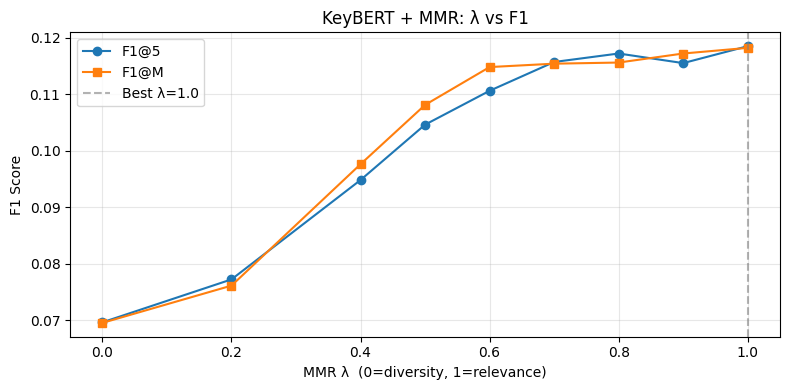

Saved: lambda_sweep.png


In [ ]:
lams    = list(sweep_results.keys())
f1k_vals = [sweep_results[l][f'F1@{EVAL_K}'] for l in lams]
f1m_vals = [sweep_results[l]['F1@M']          for l in lams]

plt.figure(figsize=(8, 4))
plt.plot(lams, f1k_vals, marker='o', label=f'F1@{EVAL_K}')
plt.plot(lams, f1m_vals, marker='s', label='F1@M')
plt.axvline(x=best_lam, color='gray', linestyle='--', alpha=0.6, label=f'Best λ={best_lam}')
plt.xlabel('MMR λ  (0=diversity, 1=relevance)')
plt.ylabel('F1 Score')
plt.title('KeyBERT + MMR: λ vs F1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lambda_sweep.png', dpi=150)
plt.show()
print('Saved: lambda_sweep.png')

## 정성 분석 — 단일 예제 시각화

KeyBERT 1차 순위와 MMR 적용 후 결과를 비교합니다.

In [ ]:
def show_example(rec: dict,
                 encoder: SentenceTransformer,
                 mmr_lambda: float,
                 top_k: int = 5):
    """
    단일 샘플의 키프레이즈 추출 과정을 단계별로 출력.

    표시 내용:
        - Gold keyphrases (정답)
        - KeyBERT 1차 순위 (유사도 점수 포함)
        - MMR 최종 선택 (다양성 반영)
    """
    document   = rec['title'] + ' . ' + rec['abstract']
    candidates = rec['candidates']
    golds      = rec['keyphrases']

    # ── KeyBERT 1차 순위 ───────────────────────────────────────
    ranked_cands, cand_embeddings, doc_embedding = keybert_rank(
        document, candidates, encoder
    )

    # ── MMR 적용 ───────────────────────────────────────────────
    mmr_result = mmr_rerank(
        doc_embedding   = doc_embedding,
        candidates      = candidates,
        cand_embeddings = cand_embeddings,
        mmr_lambda      = mmr_lambda,
        top_k           = top_k,
    )

    # ── 출력 ───────────────────────────────────────────────────
    gold_stems = {stem(g) for g in golds}

    print(f'Title   : {rec["title"]}')
    print(f'Gold KPs: {golds}\n')

    print(f'[KeyBERT Top-{top_k}] (유사도 내림차순, before MMR)')
    for kp, score in ranked_cands[:top_k]:
        hit = '✓' if stem(kp) in gold_stems else ' '
        print(f'  {hit} [{score:.4f}] {kp}')

    print(f'\n[MMR Top-{top_k}] (λ={mmr_lambda}, diversity 반영)')
    for kp in mmr_result:
        hit = '✓' if stem(kp) in gold_stems else ' '
        print(f'  {hit} {kp}')

    # 개별 F1 점수
    f1k = f1_at_k(mmr_result, golds, k=EVAL_K)
    f1m = f1_at_k(mmr_result, golds, k=len(golds))
    print(f'\n  F1@{EVAL_K}={f1k:.4f}  F1@M={f1m:.4f}')


# 3개 예제 출력
for i in range(3):
    print(f'\n{"="*65}')
    print(f'[Example {i+1}]')
    show_example(records[i], encoder, mmr_lambda=CONFIG['mmr_lambda'], top_k=CONFIG['eval_k'])


[Example 1]
Title   : A feedback vertex set of 2-degenerate graphs
Gold KPs: ['feedback vertex set', '2-degenerate graphs', 'decycling set']

Gold KPs (stemmed): {'2-degener graph', 'decycl set', 'feedback vertex set'}

[KeyBERT Top-5] (유사도 내림차순, before MMR)
    [0.6859] feedback vertex set of cardinality
    [0.6751] the cardinality of feedback vertex
    [0.5936] 2-degenerate n -vertex graph
    [0.4484] the cardinality of a feedback
    [0.3646] polynomial time algorithm

[MMR Top-5] (λ=0.6, diversity 반영)
    feedback vertex set of cardinality
    2-degenerate n -vertex graph
    polynomial time algorithm
    the cardinality of feedback vertex
    2-degree

  F1@5=0.0000  F1@M=0.0000

[Example 2]
Title   : Hybrid Analytical Modeling of Pending Cache Hits, Data Prefetching, and MSHRs
Gold KPs: ['analytical modeling', 'data prefetching', 'performance', 'miss status holding register', 'pending hit']

Gold KPs (stemmed): {'perform', 'miss statu hold regist', 'pend hit', 'analyt model',

정성 분석 결과 3가지 실패 패턴 발견:
  1. KP 경계 설정 실패 (Example 1)
     → 후처리로 max_words 제한 강화
  
  2. 유사 표현 쏠림 (Example 2, 3)
     → Contrastive Learning으로 해결 가능
  
  3. 약어/전문용어 실패 (Example 3)
     → 도메인 갭 문제, TAPT로 완화 가능

In [ ]:
# 결과 요약
rows = [
    {'Method': 'Baseline (KeyBART order)',              **baseline_results},
    {'Method': 'KeyBERT-only (λ=1.0)',                  **keybert_only},
    {'Method': f'KeyBERT+MMR (λ={CONFIG["mmr_lambda"]})', **sweep_results[CONFIG["mmr_lambda"]]},
    {'Method': f'KeyBERT+MMR (best λ={best_lam})',      **sweep_results[best_lam]},
]

df = pd.DataFrame(rows).set_index('Method')
display(df)

,P@5,R@5,F1@5,P@M,R@M,F1@M,ILD,SR,Runtime(ms),F1@5(Present),F1@5(Absent)
Method,,,,,,,,,,,
Baseline (KeyBART order),0.1268,0.1394,0.1278,0.1299,0.1299,0.1299,0.7381,0.450,18.23,0.1485,0.0230
KeyBERT-only (λ=1.0),0.1148,0.1310,0.1185,0.1182,0.1182,0.1182,0.6521,0.428,34.79,0.1369,0.0222
KeyBERT+MMR (λ=0.6),0.1084,0.1213,0.1106,0.1148,0.1148,0.1148,0.7310,0.422,35.02,0.1277,0.0213
KeyBERT+MMR (best λ=1.0),0.1148,0.1310,0.1185,0.1182,0.1182,0.1182,0.6521,0.428,35.86,0.1369,0.0222
